### GAN (5 pts)

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
import torchvision.datasets as datasets
import imageio
import numpy as np
import matplotlib
from torchvision.utils import make_grid, save_image
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from tqdm import tqdm
matplotlib.style.use('ggplot')

In [2]:
# learning parameters
batch_size = 512
epochs = 200
sample_size = 64 # fixed sample size
nz = 128 # latent vector size
k = 1 # number of steps to apply to the discriminator
device = 'cpu'

In [3]:
transform = transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize((0.5,),(0.5,)),
])
to_pil_image = transforms.ToPILImage()

In [18]:
train_data = datasets.MNIST(
    root='./input/data',
    train=True,
    download=True,
    transform=transform
)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

100%|███████████████████████████████████████| 9.91M/9.91M [00:34<00:00, 290kB/s]
100%|███████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 220kB/s]
100%|███████████████████████████████████████| 1.65M/1.65M [00:03<00:00, 492kB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.08MB/s]


In [36]:
class Generator(nn.Module):
    def __init__(self, nz):
        super(Generator, self).__init__()
        self.nz = nz
        self.main = nn.Sequential(
            nn.Linear(nz, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            
            nn.Linear(1024, 784),  # 28x28 = 784
            nn.Tanh(),
        )
        
    def forward(self, x):
        return self.main(x).view(-1, 1, 28, 28)

In [37]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.n_input = 784
        self.main = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )
        
    def forward(self, x):
        x = x.view(-1, 784)
        return self.main(x)

In [21]:
generator = Generator(nz).to(device)
discriminator = Discriminator().to(device)

In [22]:
optim_g = optim.Adam(generator.parameters(), lr=0.0002)
optim_d = optim.Adam(discriminator.parameters(), lr=0.0002)

In [23]:
criterion = nn.BCELoss()

In [24]:
losses_g = []
losses_d = []
images = []

In [25]:
def label_real(size):
    data = torch.ones(size, 1)
    return data.to(device)
def label_fake(size):
    data = torch.zeros(size, 1)
    return data.to(device)

In [26]:
def create_noise(sample_size, nz):
    return torch.randn(sample_size, nz).to(device)

In [27]:
def save_generator_image(image, path):
    save_image(image, path)

In [28]:
def train_discriminator(optimizer, data_real, data_fake):
    b_size = data_real.size(0)
    real_label = label_real(b_size)
    fake_label = label_fake(b_size)
    optimizer.zero_grad()
    output_real = discriminator(data_real)
    loss_real = criterion(output_real, real_label)
    output_fake = discriminator(data_fake)
    loss_fake = criterion(output_fake, fake_label)
    loss_real.backward()
    loss_fake.backward()
    optimizer.step()
    return loss_real + loss_fake

In [29]:
def train_generator(optimizer, data_fake):
    b_size = data_fake.size(0)
    real_label = label_real(b_size)
    optimizer.zero_grad()
    output = discriminator(data_fake)
    loss = criterion(output, real_label)
    loss.backward()
    optimizer.step()
    return loss

In [30]:
noise = create_noise(sample_size, nz)
generator.train()
discriminator.train()

Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

Epoch 0 of 200
Generator loss: 5.85577011, Discriminator loss: 0.16796099


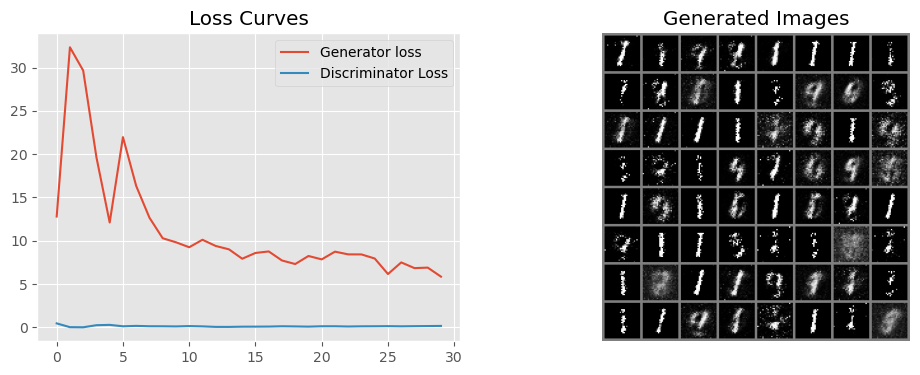

 31%|████████████▉                             | 36/117 [00:03<00:06, 11.84it/s]


KeyboardInterrupt: 

In [41]:
from IPython.display import clear_output

for epoch in range(epochs):
    loss_g = 0.0
    loss_d = 0.0
    
    for bi, data in tqdm(enumerate(train_loader), total=int(len(train_data)/train_loader.batch_size)):
        image, _ = data
        image = image.to(device)
        b_size = len(image)
 
        for step in range(k):
            data_fake = generator(create_noise(b_size, nz)).detach()
            data_real = image
            loss_d += train_discriminator(optim_d, data_real, data_fake)

        data_fake = generator(create_noise(b_size, nz))
        loss_g += train_generator(optim_g, data_fake)

    generated_img = generator(noise).cpu().detach()

    generated_img_grid = make_grid(generated_img)
    images.append(generated_img_grid)
    
    epoch_loss_g = loss_g / (bi + 1)  # total generator loss for the epoch
    epoch_loss_d = loss_d / (bi + 1)
    
    losses_g.append(epoch_loss_g)
    losses_d.append(epoch_loss_d)
    
    clear_output(wait=True)
    print(f"Epoch {epoch} of {epochs}")
    print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot([l.detach().cpu().numpy() if torch.is_tensor(l) else l for l in losses_g], label='Generator loss')
    plt.plot([l.detach().cpu().numpy() if torch.is_tensor(l) else l for l in losses_d], label='Discriminator Loss')
    plt.legend()
    plt.title('Loss Curves')

    plt.subplot(1, 2, 2)
    img_display = generated_img_grid.permute(1, 2, 0).detach().cpu().numpy()
    img_display = (img_display + 1) / 2
    plt.imshow(img_display)
    plt.title('Generated Images')
    plt.axis('off')
    plt.show()